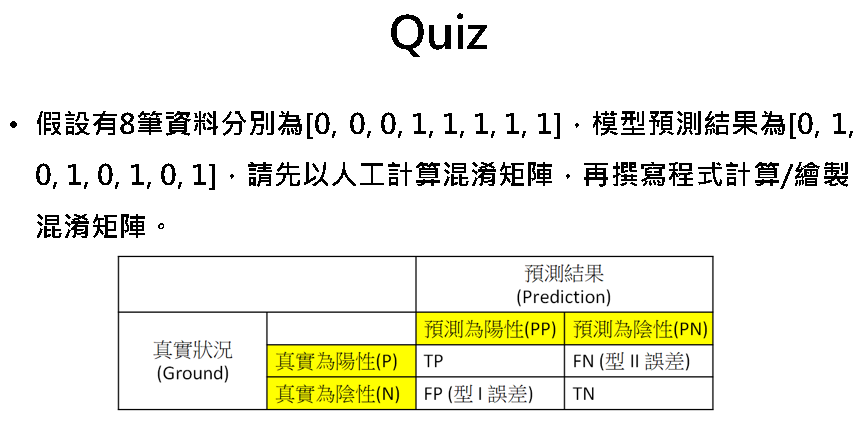

In [1]:
y_true = [0, 0, 0, 1, 1, 1, 1, 1]
y_pred = [0, 1, 0, 1, 0, 1, 0, 1]

In [ ]:
from sklearn.metrics import confusion_matrix
"""
    0   1
0  TN  FP 
1  FN  TP
"""
confusion_matrix(y_true,y_pred)


array([[2, 1],
       [2, 3]], dtype=int64)

In [4]:
"""
    1   0
1  TP  FN 
0  FP  TN
"""
confusion_matrix(y_true,y_pred,labels=[1,0])

array([[3, 2],
       [1, 2]], dtype=int64)

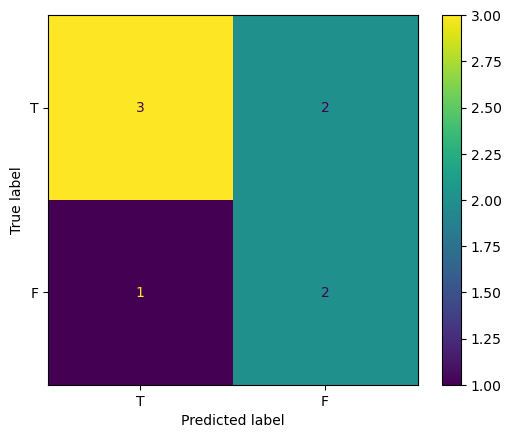

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,labels=[1,0],display_labels=["T","F"])

### 準確率 (Accuracy)
表示模型正確預測的案例（真陽性和真陰性）占所有案例的比例。公式如下：
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

### 精確率 (Precision)我要找到更多精準找到陽性的人 但可能抓錯人
表示被模型預測為陽性且實際上也為陽性的案例占所有被模型預測為陽性的案例的比例。公式如下：

降低假陽(FP)我提高了病毒的量 並度量要高才算陽 但是有些少量病毒的也因該是陽性所以FN上升
$$ \text{Precision} = \frac{TP}{TP + FP} $$

### 召回率 (Recall) 或稱敏感度 (Sensitivity) 我要找到更多陽性的人
表示被模型預測為陽性且實際上也為陽性的案例占所有實際陽性案例的比例。公式如下：

降低假英(FN)我降低了病毒的量 但是有些少量病毒就算陽 但是這要FP(假陽就可能上升)
$$ \text{Recall} = \frac{TP}{TP + FN} $$

## 精確率 與 召回率 此消彼漲
FP想變小FN有可能多 FN想變小FP可能多這就是 消彼長的關係原因

### F1 Score
為精確率與召回率的調和平均數，是兩者之間的平衡。公式如下：
$$ \text{F1 Score} = \frac{2 \times TP}{2 \times TP + FP + FN} $$

# 羅吉斯迴歸（Logistic Regression）

### 適合二分法

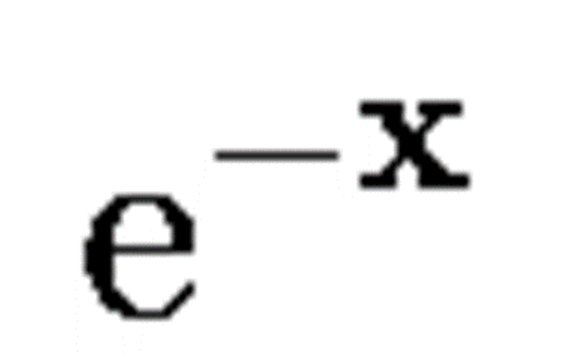


- e很大X越靠近0

- e很小X越無限大

In [7]:
import numpy as np
for x in range(-10,11):
    print(x,np.exp(-x))

-10 22026.465794806718
-9 8103.083927575384
-8 2980.9579870417283
-7 1096.6331584284585
-6 403.4287934927351
-5 148.4131591025766
-4 54.598150033144236
-3 20.085536923187668
-2 7.38905609893065
-1 2.718281828459045
0 1.0
1 0.36787944117144233
2 0.1353352832366127
3 0.049787068367863944
4 0.01831563888873418
5 0.006737946999085467
6 0.0024787521766663585
7 0.0009118819655545162
8 0.00033546262790251185
9 0.00012340980408667956
10 4.5399929762484854e-05


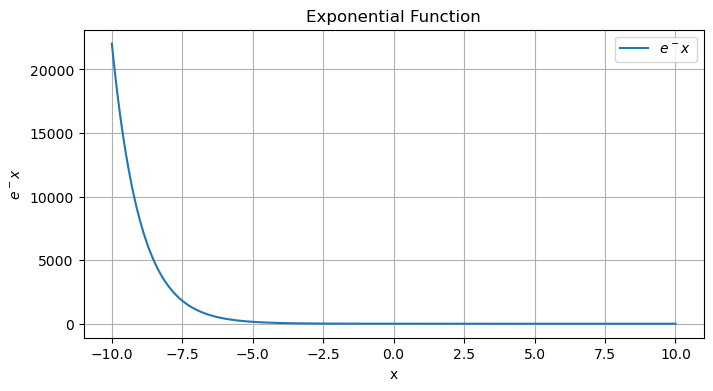

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 生成x值
x = np.linspace(-10, 10, 400)
# 計算 e^x
y = np.exp(-x)

# 繪製圖形
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$e^-x$')
plt.title('Exponential Function')
plt.xlabel('x')
plt.ylabel('$e^-x$')
plt.grid(True)
plt.legend()
plt.show()


In [9]:
import numpy as np

# 定義羅吉斯函數
def logistic_function(x):
    return 1 / (1 + np.exp(-x))

# 計算範圍從 -10 到 10 的羅吉斯函數值
x_values = np.linspace(-10, 10, 21)  # 產生從 -10 到 10 的21個點
logistic_values = logistic_function(x_values)

# 輸出結果
list(zip(x_values, logistic_values))

[(-10.0, 4.5397868702434395e-05),
 (-9.0, 0.00012339457598623172),
 (-8.0, 0.0003353501304664781),
 (-7.0, 0.0009110511944006454),
 (-6.0, 0.0024726231566347743),
 (-5.0, 0.0066928509242848554),
 (-4.0, 0.01798620996209156),
 (-3.0, 0.04742587317756678),
 (-2.0, 0.11920292202211755),
 (-1.0, 0.2689414213699951),
 (0.0, 0.5),
 (1.0, 0.7310585786300049),
 (2.0, 0.8807970779778823),
 (3.0, 0.9525741268224334),
 (4.0, 0.9820137900379085),
 (5.0, 0.9933071490757153),
 (6.0, 0.9975273768433653),
 (7.0, 0.9990889488055994),
 (8.0, 0.9996646498695336),
 (9.0, 0.9998766054240137),
 (10.0, 0.9999546021312976)]

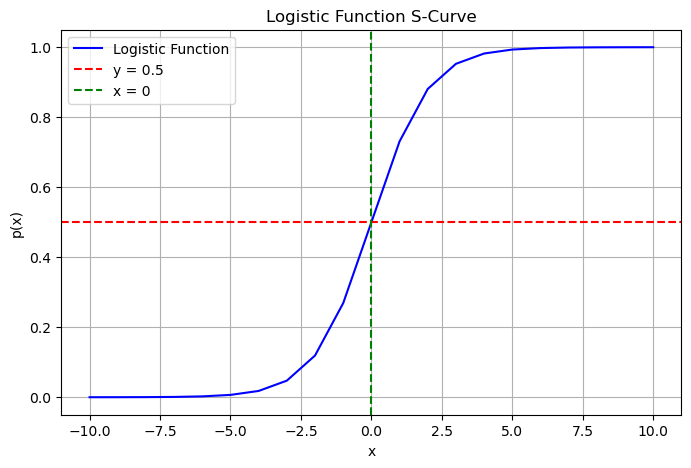

In [10]:
import matplotlib.pyplot as plt

# 使用上一步計算的數據來繪製羅吉斯函數的圖
plt.figure(figsize=(8, 5))
plt.plot(x_values, logistic_values, label='Logistic Function', color='blue')
plt.title('Logistic Function S-Curve')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='y = 0.5')
plt.axvline(x=0, color='g', linestyle='--', label='x = 0')
plt.legend()
plt.show()


## 數據

一項實驗對5000名參與者進行了研究，以研究年齡和身體健康對聽力損失，特別是對聽到高音頻聲音的影響。這些數據顯示了研究的結果，參與者被評估並獲得身體能力分數，然後進行音頻測試（通過/不通過），以評估他們聽到高頻聲音的能力。同時記錄了參與者的年齡。是否有可能根據參與者的特徵（年齡和身體分數）建立一個模型來預測某人聽到高頻聲音的可能性？

* 特徵

    * age - 參與者的年齡（以年為單位）
    * physical_score - 身體測試中獲得的分數

* 標籤/目標

    * test_result - 如果未通過，則為0；如果通過測試，則為1

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [14]:
df = pd.read_csv("./hearing_test.csv")

In [16]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [19]:
df2 = df.sort_values(by="age",ascending=False)
df2[df2["test_result"] == 1]

,age,physical_score,test_result
1075,71.0,28.4,1
3693,71.0,31.9,1
4428,69.0,30.9,1
3407,68.0,33.0,1
3895,68.0,28.6,1
...,...,...,...
2268,22.0,41.8,1
454,22.0,49.5,1
1187,21.0,46.5,1
3196,21.0,46.3,1


In [20]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [21]:
df["test_result"].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='physical_score'>

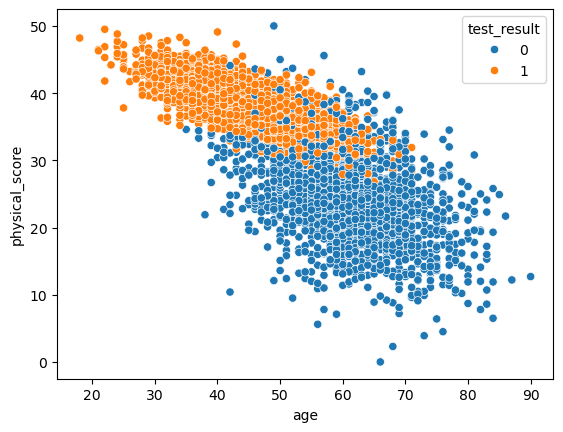

In [22]:
sns.scatterplot(x="age",y="physical_score",data=df,hue="test_result")

<Axes: >

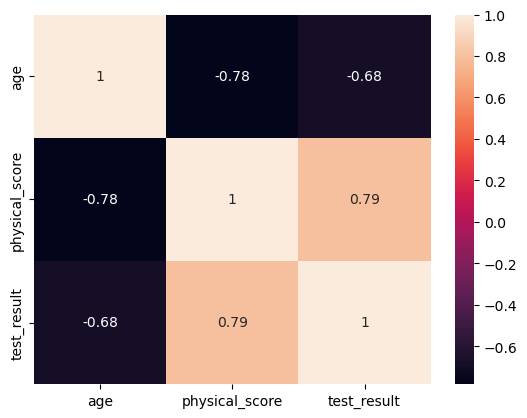

In [24]:
sns.heatmap(df.corr(),annot=True)

In [25]:
X = df.drop("test_result",axis=1)
y = df["test_result"]


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)


In [27]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [28]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [29]:
from sklearn.metrics import accuracy_score, classification_report

In [30]:
y_pred = log_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.93

In [33]:
print(classification_report(y_test,y_pred))
#準確率 (Accuracy)
#精確率 (Precision)
#召回率 (Recall) 

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

## 預測信用卡詐騙
### 資料:
https://drive.google.com/file/d/1acrq0RJkVElq8jf_8jq0-X2TDcJvxjcf/view?usp=sharing

In [35]:
df = pd.read_csv("./creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [36]:
X,y = df.drop(["Time","Amount","Class"],axis=1),df["Class"]
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153


In [37]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [38]:
df.Class.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
clf = LogisticRegression().fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9990871107053826

In [41]:
from sklearn.metrics import confusion_matrix
tn,fp,fn,tp = confusion_matrix(y_test,y_pred).ravel()
tn,fp,fn,tp

(56854, 10, 42, 56)

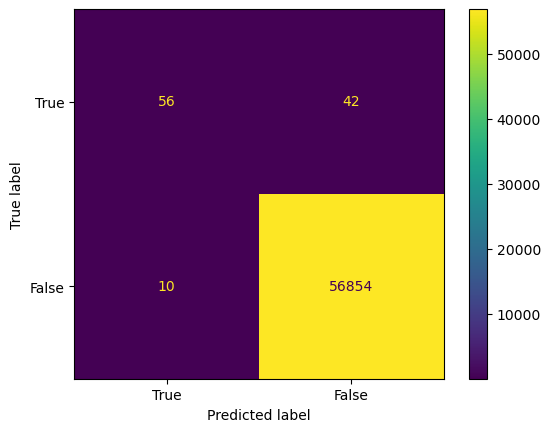

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,labels=[1,0],display_labels=["True","False"])


In [48]:
print(f"準確率:{(tn +tp) / (tn+tp+fn+fp):.5f}" )
print(f"精確率:{tp/(tp+fp):.3f}")
print(f"招回率:{tp/(tp+fn):.3f}")

準確率:0.99909
精確率:0.848
招回率:0.571


# Multi-Class Logistic Regression


In [49]:
df = pd.read_csv("./iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [50]:
X = df.drop("species",axis=1)
y = df["species"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=101)
scaler = StandardScaler()
scaled_X_train  = scaler.fit_transform(X_train)
scaled_X_test  = scaler.transform(X_test)


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier#分類問題轉化為多個二元分類問題
#saga 才可使用l1 l2
log_mod = LogisticRegression(solver="saga",max_iter=5000)
oneVsRest_model =  OneVsRestClassifier(log_mod)


In [53]:
penalty = ["l1","l2"]
"""
0 表示10^0 = 1 開始
4 表示10^4 = 10000 結束
10 分10斷
指數範圍從10^0 到 10^4平均切10個點
"""
C = np.logspace(0,4,10)
print(C)
#C 越小，正則化強度越大
grid_model = GridSearchCV(oneVsRest_model, param_grid={'estimator__C': C,
                                                  'estimator__penalty': penalty})
grid_model.fit(scaled_X_train,y_train)

[1.00000000e+00 2.78255940e+00 7.74263683e+00 2.15443469e+01
 5.99484250e+01 1.66810054e+02 4.64158883e+02 1.29154967e+03
 3.59381366e+03 1.00000000e+04]


GridSearchCV(estimator=OneVsRestClassifier(estimator=LogisticRegression(max_iter=5000,
                                                                        solver='saga')),
             param_grid={'estimator__C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'estimator__penalty': ['l1', 'l2']})

In [54]:
y_pred = grid_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

1.0

## Pipeline 的好處，可以從以下幾個關鍵點進行說明：

1. **簡化代碼**：
   - 使用 `Pipeline` 可以將數據預處理、特徵選擇、降維和模型訓練的步驟整合在一起，這樣就可用一行代碼來執行這些順序性的步驟，使代碼更加整潔、易於理解和維護。

2. **避免數據洩露**：
   - 在機器學習中，數據洩露是一個常見問題，特別是在數據預處理階段。`Pipeline` 確保預處理如標準化或正規化僅使用來自訓練數據的信息，並且每次交叉驗證的時候都是獨立處理，從而避免測試數據信息在模型訓練過程中被不當使用。

3. **便於進行模型選擇和調參**：
   - `Pipeline` 可以與 `GridSearchCV` 或 `RandomizedSearchCV` 結合使用，這讓我們可以同時對轉換器和預測器的參數進行調整。這種結合使用可以在模型選擇和超參數調整階段大大提高效率。

4. **提升模型的重用性和部署**：
   - 使用 `Pipeline` 可以將所有預處理步驟和預測模型封裝成單一對象，這使得模型從開發環境到生產環境的遷移更加順暢。此外，這種封裝還有助於確保在不同數據集上應用模型時，所有步驟都會按照相同的順序和方式執行。

5. **自動化工作流程**：
   - `Pipeline` 能夠自動處理在對新數據進行預測時所需的所有步驟，如轉換和預測，用戶只需調用 `fit` 和 `predict` 方法。這減少了手動錯誤的風險，提高了工作效率。

In [56]:
import pandas as pd
df = pd.read_csv("./california_housing_data.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [57]:
X = df.drop("target",axis=1)
y = df["target"]

In [58]:
from sklearn.model_selection import train_test_split
# 將數據分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


## 建立管道

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LinearRegression

In [60]:
pipline = Pipeline([
    ("scaler",StandardScaler()),
    ("regression",LinearRegression())
])

In [61]:
pipline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('regression', LinearRegression())])

In [62]:
from sklearn.metrics import mean_squared_error
y_pred = pipline.predict(X_test)
mean_squared_error(y_test,y_pred)

0.5289841670367208

## GridSearchCV and Pipline

In [63]:
import pandas as pd
df = pd.read_csv("./california_housing_data.csv")
X = df.drop("target",axis=1)
y = df["target"]

In [65]:
from sklearn.model_selection import train_test_split,GridSearchCV
# 將數據分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import Ridge


In [ ]:
pipline = Pipeline([
    ("scaler",StandardScaler()),
    ("ridge",Ridge())
])

In [68]:
parameterd = {
    "ridge__alpha":[0.1,1,10,15,20,25,30]
}
grid_search = GridSearchCV(pipline,parameterd,cv=5)
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)

{'ridge__alpha': 15}


In [70]:
y_pred = grid_search.predict(X_test)
mean_squared_error(y_test,y_pred)

0.5291802214076735

# KNN - K最近鄰居 - 分類

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("./gene_expression.csv")
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


<Axes: xlabel='Gene One', ylabel='Gene Two'>

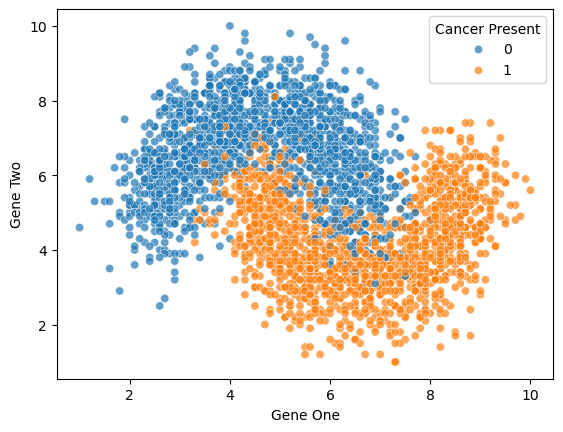

In [74]:
sns.scatterplot(x="Gene One",y="Gene Two",hue="Cancer Present",data=df,alpha=0.7)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [76]:
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [78]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [84]:
from sklearn.neighbors import KNeighborsClassifier
knn_mode = KNeighborsClassifier(n_neighbors=19)
knn_mode.fit(scaled_X_train,y_train)

KNeighborsClassifier(n_neighbors=19)

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score 
y_pred = knn_mode.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.9477777777777778

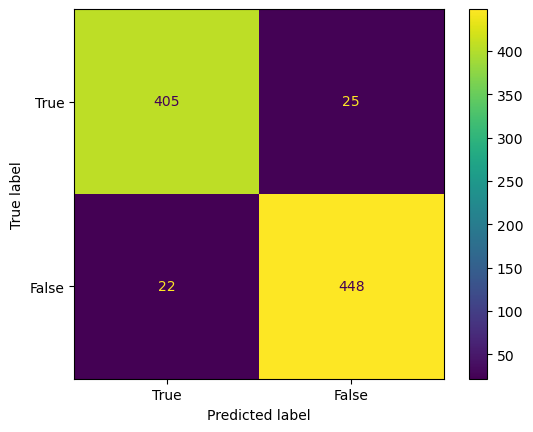

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                              labels=[1, 0],           
                              display_labels=['True', 'False']);

In [82]:
test_error_rates = []
for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train) 
   
    y_pred_test = knn_model.predict(scaled_X_test)
    
    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

Text(0.5, 0, 'K Value')

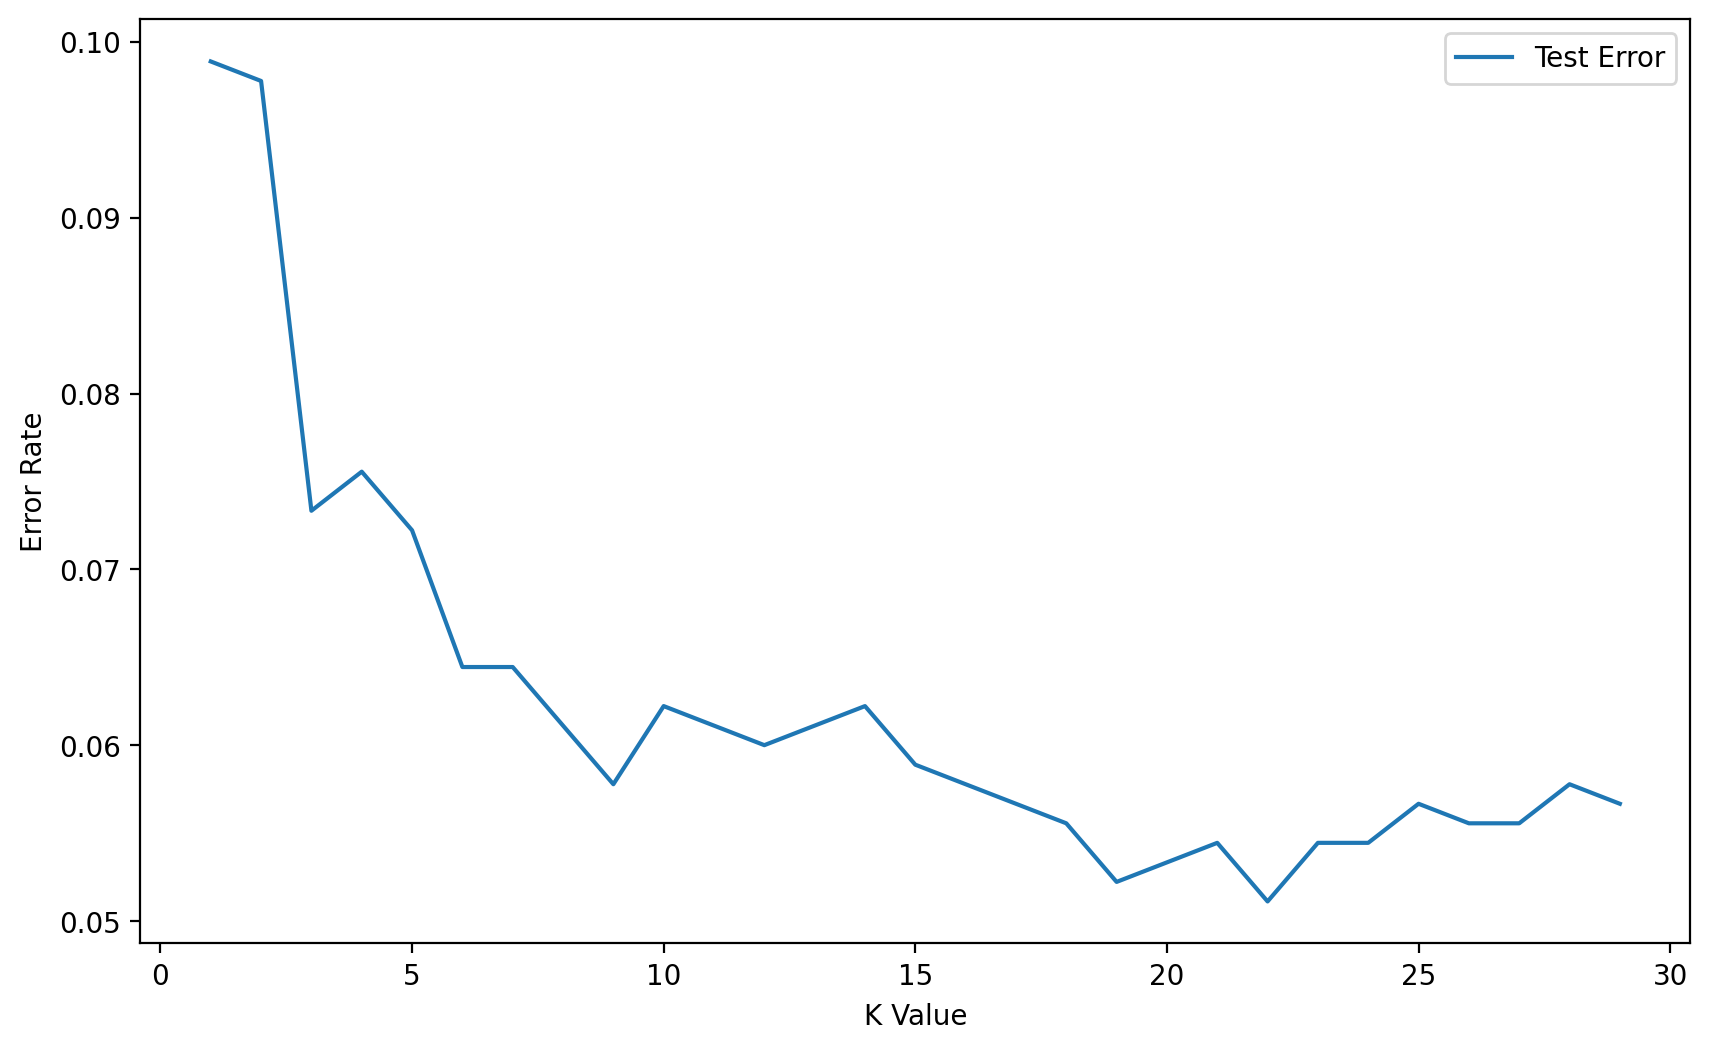

In [83]:
plt.figure(figsize=(10,6),dpi=200)
plt.plot(range(1,30),test_error_rates,label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv("./gene_expression.csv")

In [88]:
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [89]:
scaler = StandardScaler()
knn = KNeighborsClassifier()
from sklearn.pipeline import Pipeline

In [90]:
oprations = [
    ("scaler",scaler),
    ("knn",knn)
]
pipe = Pipeline(oprations)

In [91]:
from sklearn.model_selection import GridSearchCV

In [92]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [93]:
k_values = list(range(1,25))
param_grid = {"knn__n_neighbors":k_values}
grid_search = GridSearchCV(pipe,param_grid,cv=5,scoring="accuracy")
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24]},
             scoring='accuracy')

In [94]:
grid_search.best_params_

{'knn__n_neighbors': 20}

In [95]:
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=20)
oprations = [("scaler",scaler),("knn",knn)]
pipe = Pipeline(oprations)
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
accuracy_score(y_test,y_pred)

0.9466666666666667

# 探索支持向量機（Support Vector Machines, SVM）

**注意：在這個範例中，我們將探討算法，所以我們將跳過數據標準化和訓練/測試拆分，而是看看各種參數如何改變SVM（在分類中最容易視覺化效果）**

[關於SVM的優秀論文鏈接](http://citeseerx.ist.psu.edu/viewdoc/download;jsessionid=4448154647BC7B10C991CEF2236BBA38?doi=10.1.1.114.4288&rep=rep1&type=pdf)
* A tutorial on support vector regression by ALEX J. SMOLA and BERNHARD SCHOLKOPF

## SVM - 分類

### 簡介
支持向量機（Support Vector Machines，SVM）是一種監督學習模型，通常用於分類和回歸分析。SVM的目標是找到一個最佳的超平面來將數據點分開，這個超平面可以最大化邊界（即支持向量）。

### 參數
在探索SVM的過程中，有幾個重要的參數需要理解和調整：
1. **核函數（Kernel Function）**：核函數將低維空間的數據轉換到高維空間，使得數據在高維空間中更容易分離。常見的核函數包括線性核、多項式核和高斯徑向基核（RBF核）。

2. **C參數（正則化參數）**：C值控制的是誤分類的懲罰程度。較小的C值會產生一個更平滑的決策邊界，但可能會容忍更多的誤分類；較大的C值會努力正確分類所有訓練樣本，但可能導致過擬合。

3. **γ參數（gamma）**：γ參數適用於多項式核和RBF核。γ值決定了單個訓練樣本的影響範圍。較大的γ值會使得決策邊界更加複雜，較小的γ值會使得決策邊界更平滑。

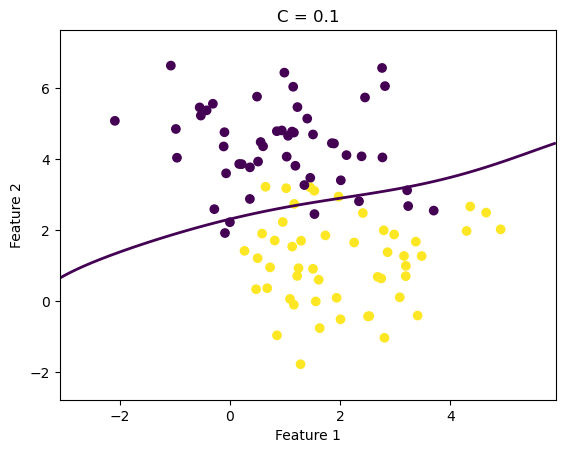

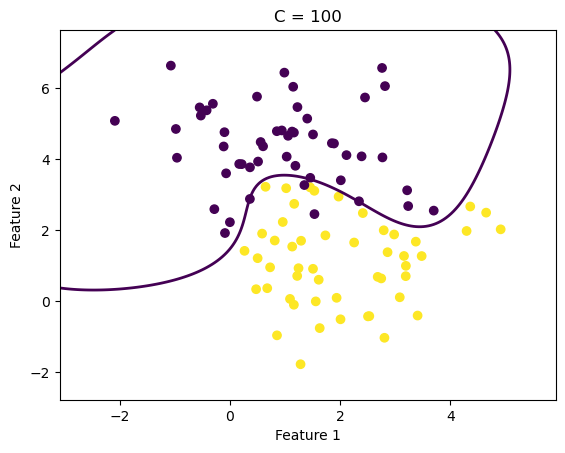

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

# Compare decision boundaries for small and large C values
#gamma='scale' 會根據資料特徵的「維度」和「變異程度」自動調整，
for C in [0.1, 100]:
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    clf.fit(X, y)
    
    # Create a mesh to plot decision boundary
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure()
    plt.contour(xx, yy, Z, levels=[0], linewidths=2)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f'C = {C}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 數據

這裡顯示的數據模擬了一項醫學研究，在該研究中，被病毒感染的小鼠被給予不同劑量的兩種藥物，然後在兩週後檢查它們是否仍然被感染。根據這些數據，我們的目標是創建一個分類模型，預測（給定兩個劑量測量值）小鼠是否仍然會被病毒感染。

你會注意到，這些群組非常容易分離，這是故意設計的，以便探索SVM模型的各種參數如何表現。

In [98]:
df = pd.read_csv("mouse_viral_study.csv")
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

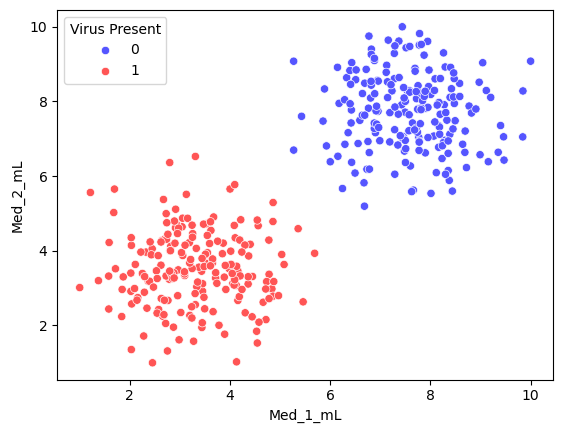

In [99]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',
                data=df,palette='seismic')

In [100]:
from sklearn.svm import SVC # Supprt Vector Classifier
import warnings
# 忽略 scikit-learn 的 UserWarning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [101]:
y = df['Virus Present']
X = df.drop('Virus Present',axis=1)

In [102]:
model = SVC(kernel='linear', C=1000)
model.fit(X, y)

SVC(C=1000, kernel='linear')

## Hyper Parameters
### C
正則化參數。正則化的強度與C值成反比(inversely)。C值必須是正數。懲罰項為平方的l2懲罰。

注意：如果你在跟隨等式特別是ISLR中描述的C值，scikit-learn中的C值與該值成反比(inversely)。


這張圖展示了使用支持向量機（SVM）模型對數據進行分類的結果，不同於之前的C值設置（C=1000），這次的C值被設置為0.05。讓我們來分析這張圖：

1. **決策邊界（實線）**：圖中的實線是SVM模型找到的分離超平面。在二維空間中，這條線將數據點分為兩個不同的區域，每個區域代表一個類別。

2. **支持向量（圈出來的點）**：有更多的數據點被圈出來了，這些點就是支持向量。相比之前的圖，支持向量的數量增加了。支持向量是距離決策邊界最近的數據點，它們對決策邊界的位置有著決定性的影響。

3. **邊界線（虛線）**：圖中的兩條虛線表示決策邊界的邊界線，它們是根據支持向量的位置來確定的。這些虛線之間的距離就是所謂的「邊界」，SVM的目標是最大化這個邊界，以便更好地將兩類數據分開。

4. **C值的影響**：在這個圖中，C值設置為0.05。較小的C值表示模型對於誤分類有更大的容忍度，因此決策邊界更平滑。這也導致了更多的數據點成為支持向量，這些點對決策邊界有更大的影響。

C 大：犯錯很貴 → 模型會很努力「不要分錯」
可能會把決策線拉得很貼近資料、甚至為了少數怪點去彎來彎去（比較容易過度貼合資料）。

C 小：犯錯比較不貴 → 模型願意「容忍一些分錯」
會更重視把中間留出一條比較寬、比較穩的安全距離（邊界 margin 變大），決策線通常更平滑、更不容易被少數怪點影響。

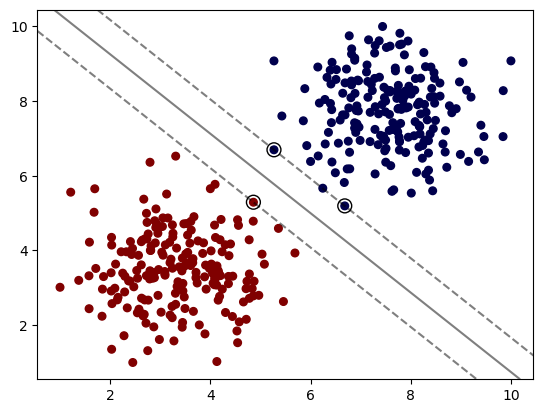

In [103]:
from svm_margin_plot import plot_svm_boundary
plot_svm_boundary(model,X,y)# 繪製SVM決策邊界

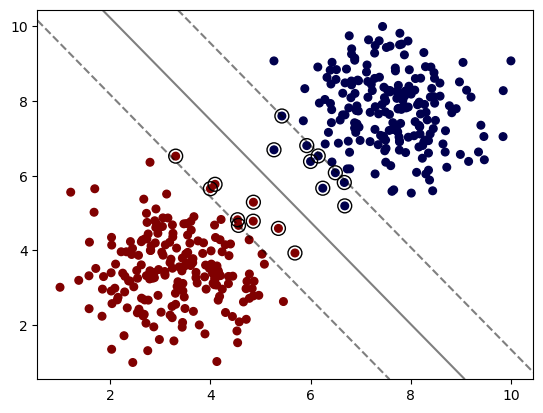

In [104]:
model = SVC(kernel='linear', C=0.05)
model.fit(X, y)
plot_svm_boundary(model,X,y)# 繪製SVM決策邊界

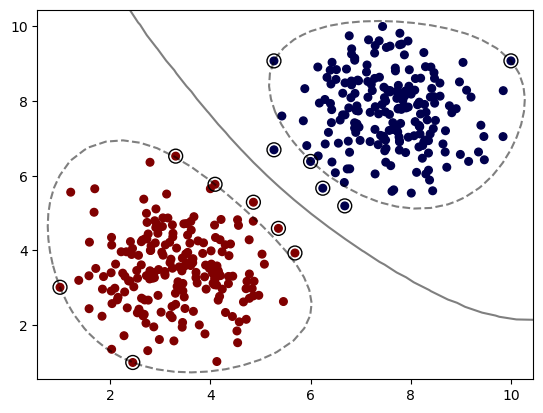

In [105]:
#特點：能夠處理非線性關係，適用於大多數情況。gamma值越大，影響範圍越小，決策邊界越複雜。
model = SVC(kernel='rbf', C=1)
model.fit(X, y)
plot_svm_boundary(model,X,y)

## gamma值的理解

- **gamma值越大**：
  - 模型會更加關注訓練數據中非常接近的資料點。
  - 因為模型更緊密地擬合這些局部數據，所以可能會導致過擬合（overfitting）。

- **gamma值越小**：
  - 模型會考慮更廣泛的資料範圍，訓練時更多地關注整體數據分佈。
  - 因此，模型更均勻地適應數據，但可能會導致欠擬合（underfitting），因為它忽略了數據中的一些細節。

這樣的表述能更清晰地傳達gamma值對模型的影響。

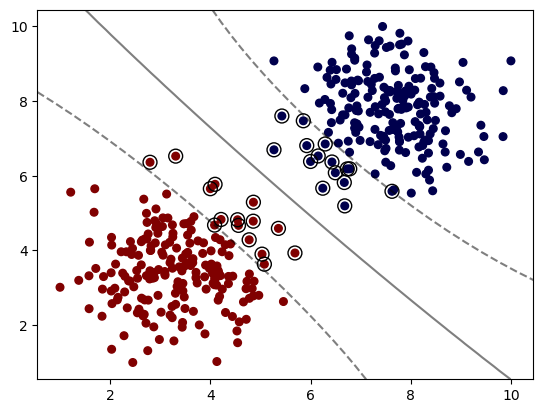

In [106]:
model = SVC(kernel='rbf', C=1,gamma=0.01)
model.fit(X, y)
plot_svm_boundary(model,X,y)

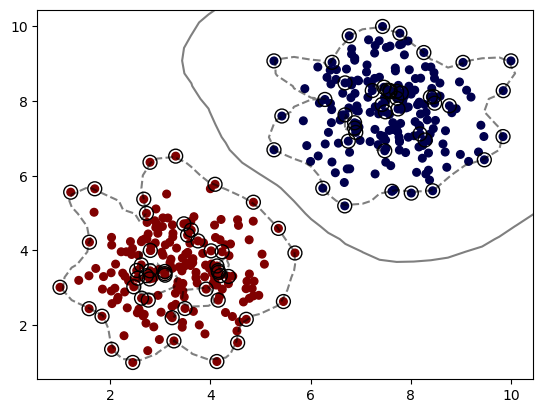

In [107]:
model = SVC(kernel='rbf', C=1,gamma=1)
model.fit(X, y)
plot_svm_boundary(model,X,y)

## 網格搜索
請記住，對於這個簡單的例子，我們看到類別很容易分開，這意味著每種模型變體都可以輕鬆獲得100%的準確率，這也意味著網格搜索在這種情況下是「無用的」。

In [108]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import pandas as pd
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# 產生「月牙形」資料（適合 RBF）
X_np, y_np = make_moons(
    n_samples=300,
    noise=0.12,
    random_state=42
)

monX = pd.DataFrame(X_np, columns=["x1", "x2"])
mony = pd.Series(y_np)

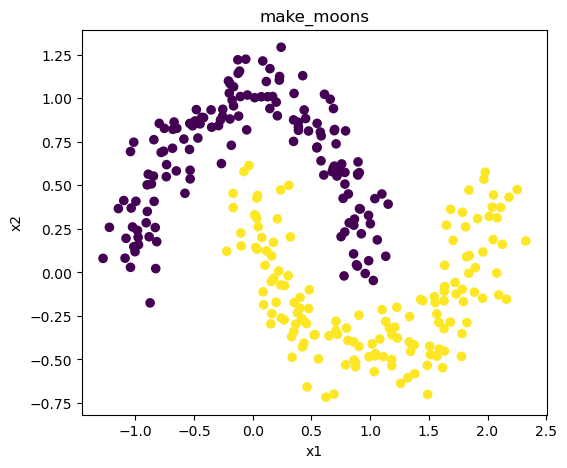

In [110]:
# 畫散點圖
plt.figure(figsize=(6, 5))
plt.scatter(monX["x1"], monX["x2"], c=mony, s=35)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons")
plt.show()

In [111]:
# 1) 要測的參數範圍（常用：用 10 倍去試）
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]  # 固定用 rbf，因為你本來就是 rbf
}


In [ ]:
# 2) 交叉驗證切法（分類建議用 StratifiedKFold）
#根據資料的分類比例切 例如 1分類 70% 0分類 30%每次切分盡力這個比例 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3) GridSearchCV
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="accuracy",  
    cv=cv,
)

In [113]:
# 4) 開始找最佳參數
grid.fit(monX, mony)

print("最佳參數:", grid.best_params_)
print("最佳CV分數:", grid.best_score_)

最佳參數: {'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}
最佳CV分數: 1.0


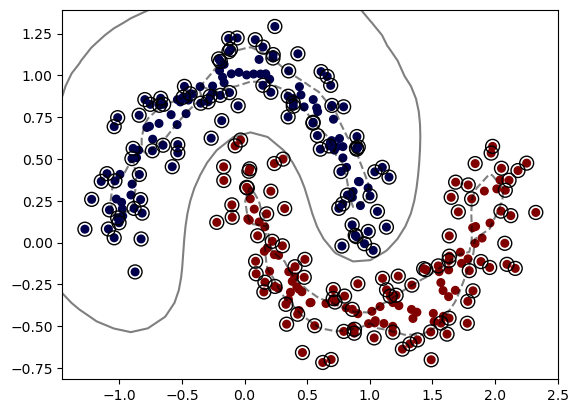

In [ ]:
# 5) 直接拿最佳模型來畫（ plot_svm_boundary）
best_model = grid.best_estimator_
plot_svm_boundary(best_model, monX, mony)


我們將使用“Palmer Penguins”數據集，這個數據集足夠簡單，可以幫助我們完全理解超參數改變如何影響分類結果。

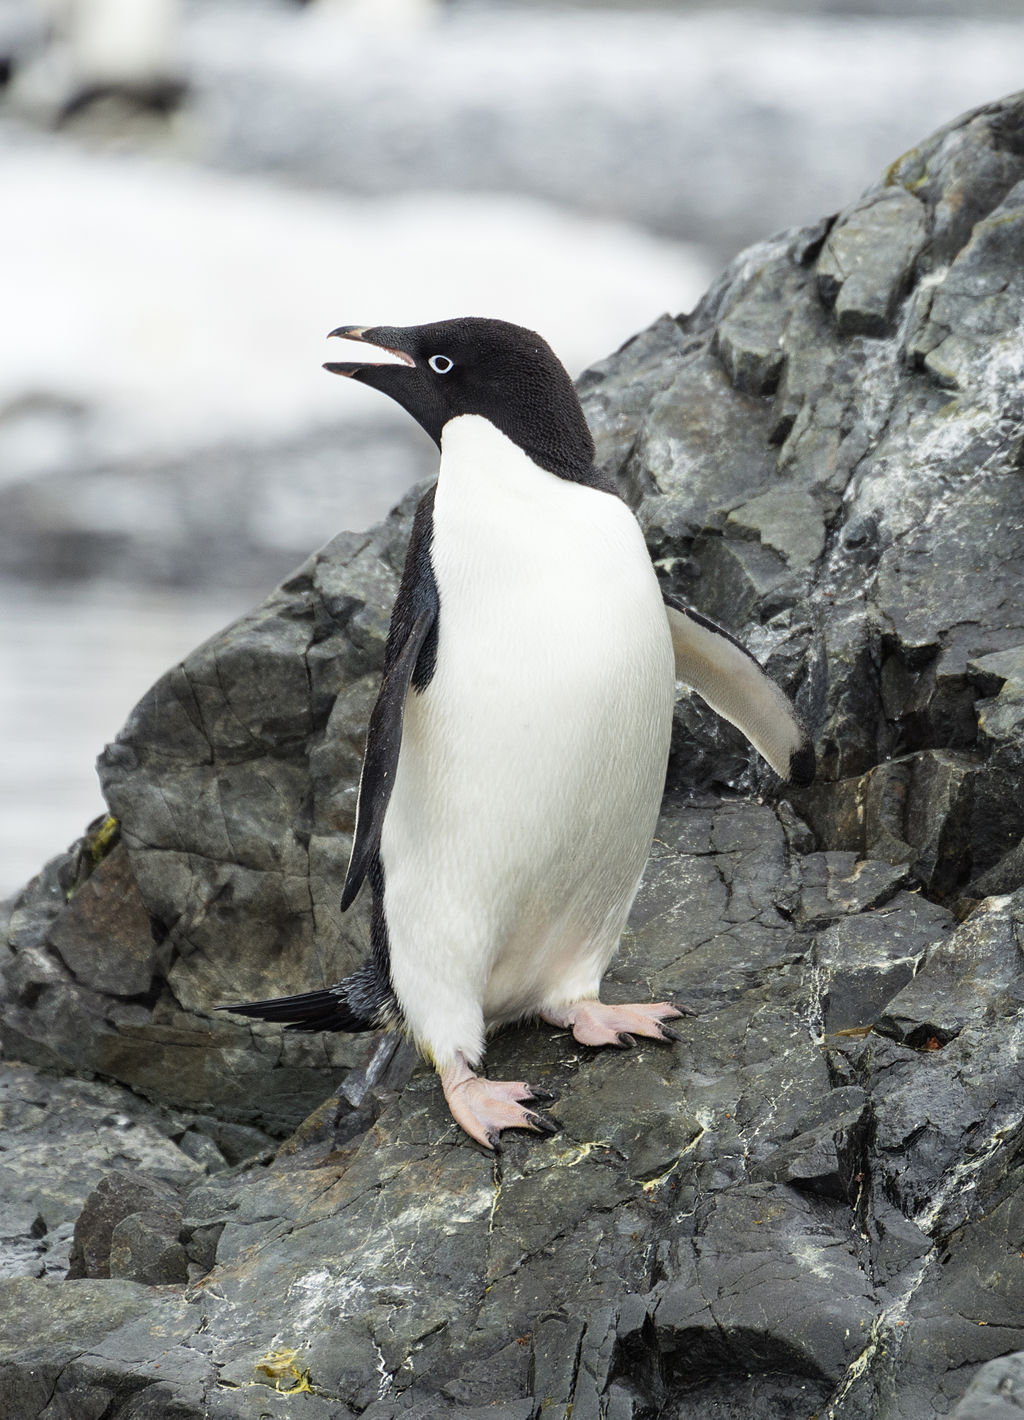
些數據由Dr. Kristen Gorman和Palmer Station，南極LTER（一個長期生態研究網絡的成員）收集並提供。

Gorman KB, Williams TD, Fraser WR (2014) 《Ecological Sexual Dimorphism and Environmental Variability within a Community of Antarctic Penguins (Genus Pygoscelis)》。PLoS ONE 9(3): e90081. doi:10.1371/journal.pone.0090081



* penguins_size.csv：簡化的數據來自原始企鵝數據集。包含變量：

    * species：企鵝物種（帽帶企鵝、阿德利企鵝或紐帶企鵝）
    * culmen_length_mm：嘴峰長度（毫米）
    * culmen_depth_mm：嘴峰深度（毫米）
    * flipper_length_mm：鰭長度（毫米）
    * body_mass_g：體重（克）
    * island：在Palmer群島（南極洲）的島嶼名稱（Dream, Torgersen或Biscoe）
    * sex：企鵝性別

註：嘴峰是“鳥喙的上脊”

**我們的目標是創建一個模型，該模型可以根據物理屬性幫助預測企鵝的物種，然後我們可以使用該模型幫助研究人員在現場分類企鵝，而無需經驗豐富的生物學家**

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [117]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [118]:
df.dropna(inplace=True)
df.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [119]:
df["sex"].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [120]:
df = df[df["sex"] != '.']

<Axes: xlabel='culmen_length_mm', ylabel='culmen_depth_mm'>

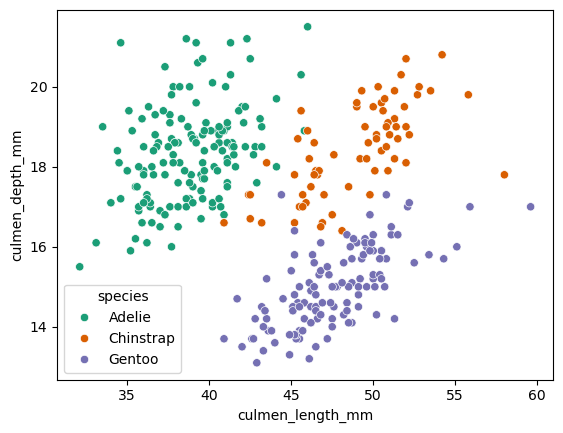

In [121]:
sns.scatterplot(x="culmen_length_mm",y='culmen_depth_mm',data=df,hue="species",palette="Dark2")

In [122]:
X = pd.get_dummies(df.drop('species',axis=1),drop_first=1 )#get_dummies One-Hot Encoding
y = df['species']

In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [125]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [126]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [127]:
base_pred =  model.predict(X_test)

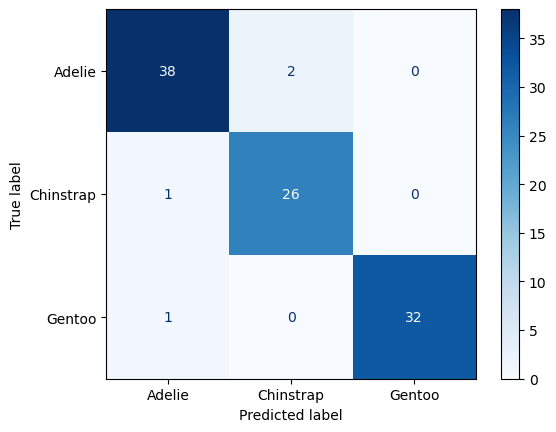

In [128]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
cm  = confusion_matrix(y_test,base_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Visualize the Tree

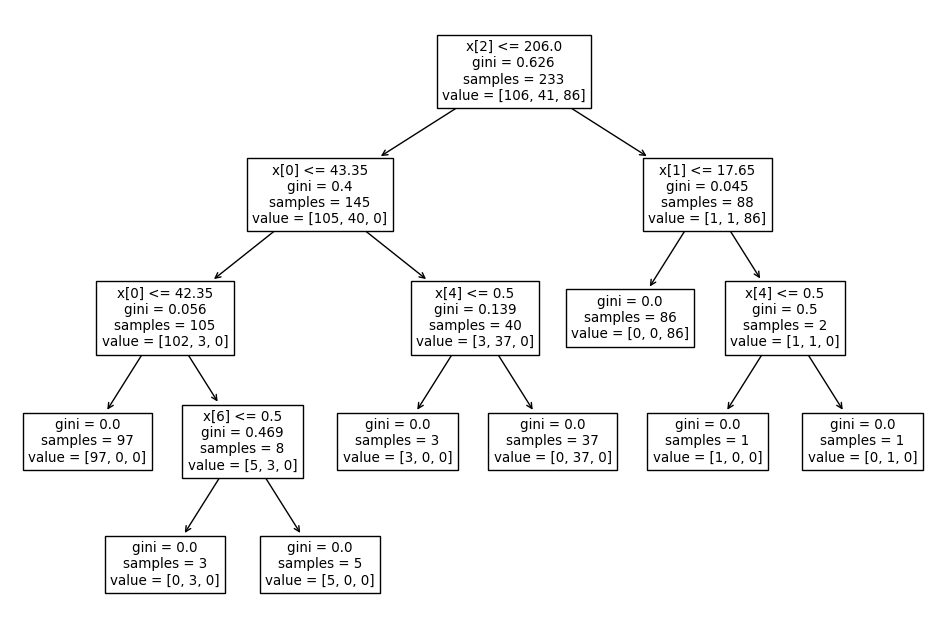

In [129]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model)
plt.show()

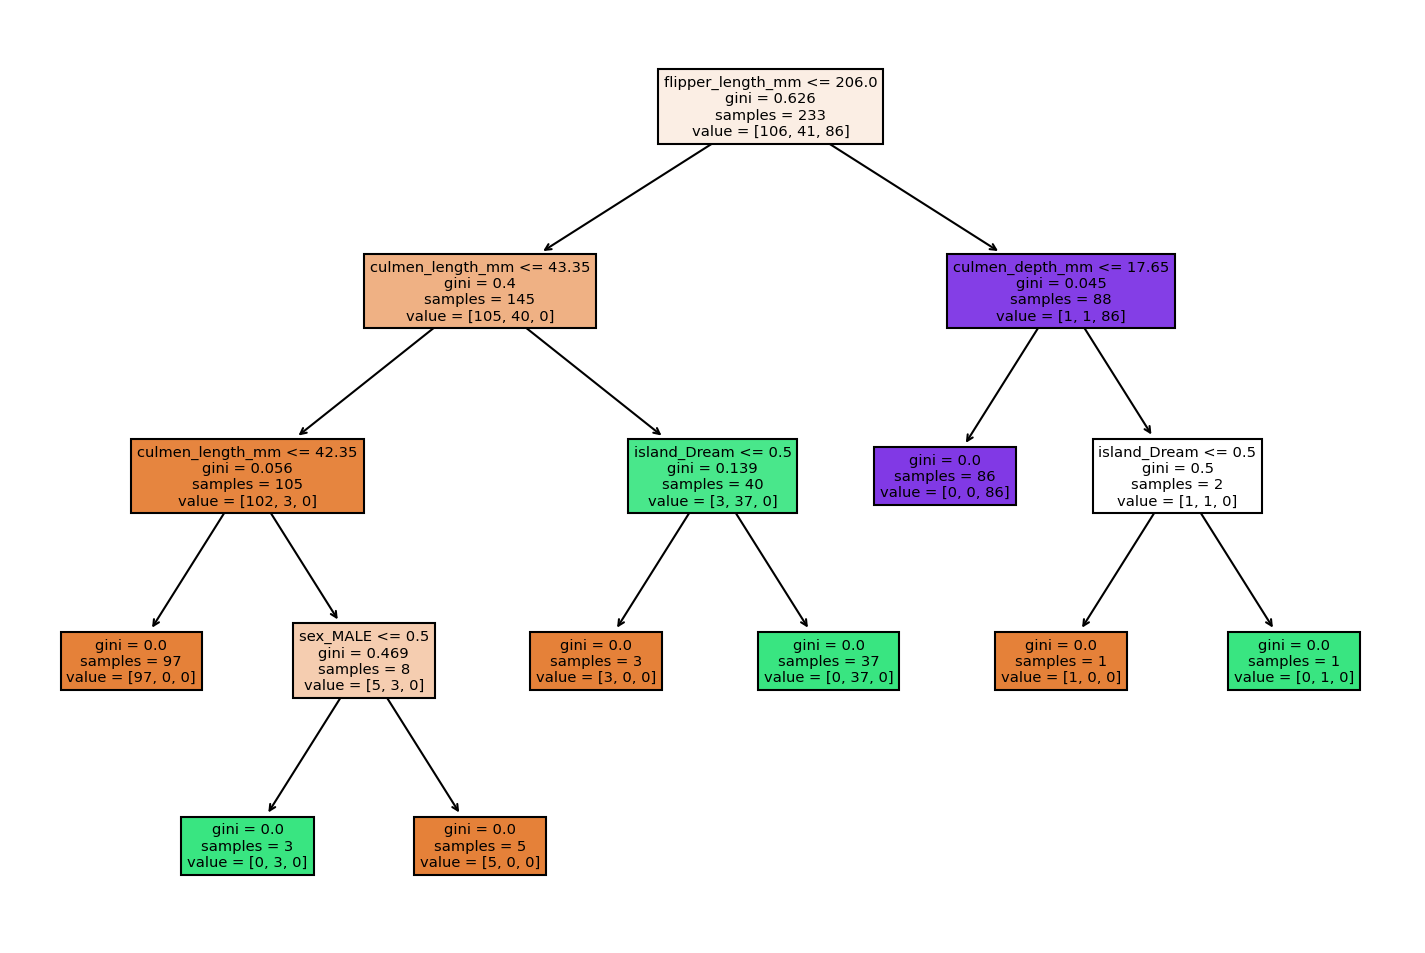

In [130]:
plt.figure(figsize=(12,8),dpi=150)
plot_tree(model,filled=True,feature_names=X.columns)
plt.show()

# Random Forest - Classification



### Random Forests (隨機森林)
1. **多個決策樹組成**：
   - 隨機森林由多個決策樹（樹的數量稱為樹的數量）組成，每棵樹獨立生成。
   - 每棵樹只使用訓練數據的一部分（通過Bootstrap隨機抽樣）和隨機選擇的一部分特徵。

2. **集成學習方法**：
   - 隨機森林是一種集成學習方法，通過結合多個決策樹的預測結果來提高模型的準確性和穩定性。
   - 對於分類任務，隨機森林通過投票方式決定最終類別；對於回歸任務，通過平均所有樹的預測結果來獲得最終結果。

3. **抗過擬合能力強**：
   - 隨機森林由於綜合了多棵樹的預測結果，減少了單棵樹過擬合的風險，具有更好的泛化能力。
   - 通過引入隨機性來減少模型的變異性，提高了預測準確性。

### 總結
- **決策樹**適用於需要簡單解釋和快速預測的情況，但容易過擬合。
- **隨機森林**則通過多棵樹的結合，提供了更高的準確性和穩定性，適用於更複雜的問題。

這些差異使得隨機森林在實際應用中更加常用，特別是在需要高準確性和穩定性的任務中。

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
df = pd.read_csv("penguins_size.csv")
df = df.dropna()
df = df[df["sex"] != '.']#過濾是.的性別
X = pd.get_dummies(df.drop("species",axis=1),drop_first=True)
y =  df["species"]

In [133]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [135]:
from sklearn.ensemble import RandomForestClassifier
# n_estimators 決策樹的數量

model = RandomForestClassifier(n_estimators=103,random_state=101)
model.fit(X_train,y_train)
preds = model.predict(X_test)

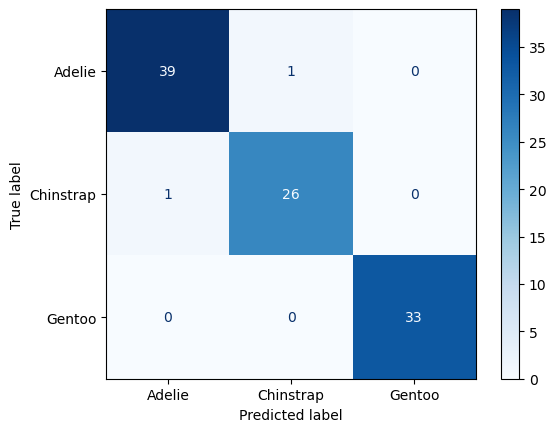

In [136]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

cm = confusion_matrix(y_test,preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
df = pd.read_csv("./rock_density_xray.csv")
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


<Axes: xlabel='Signal', ylabel='Density'>

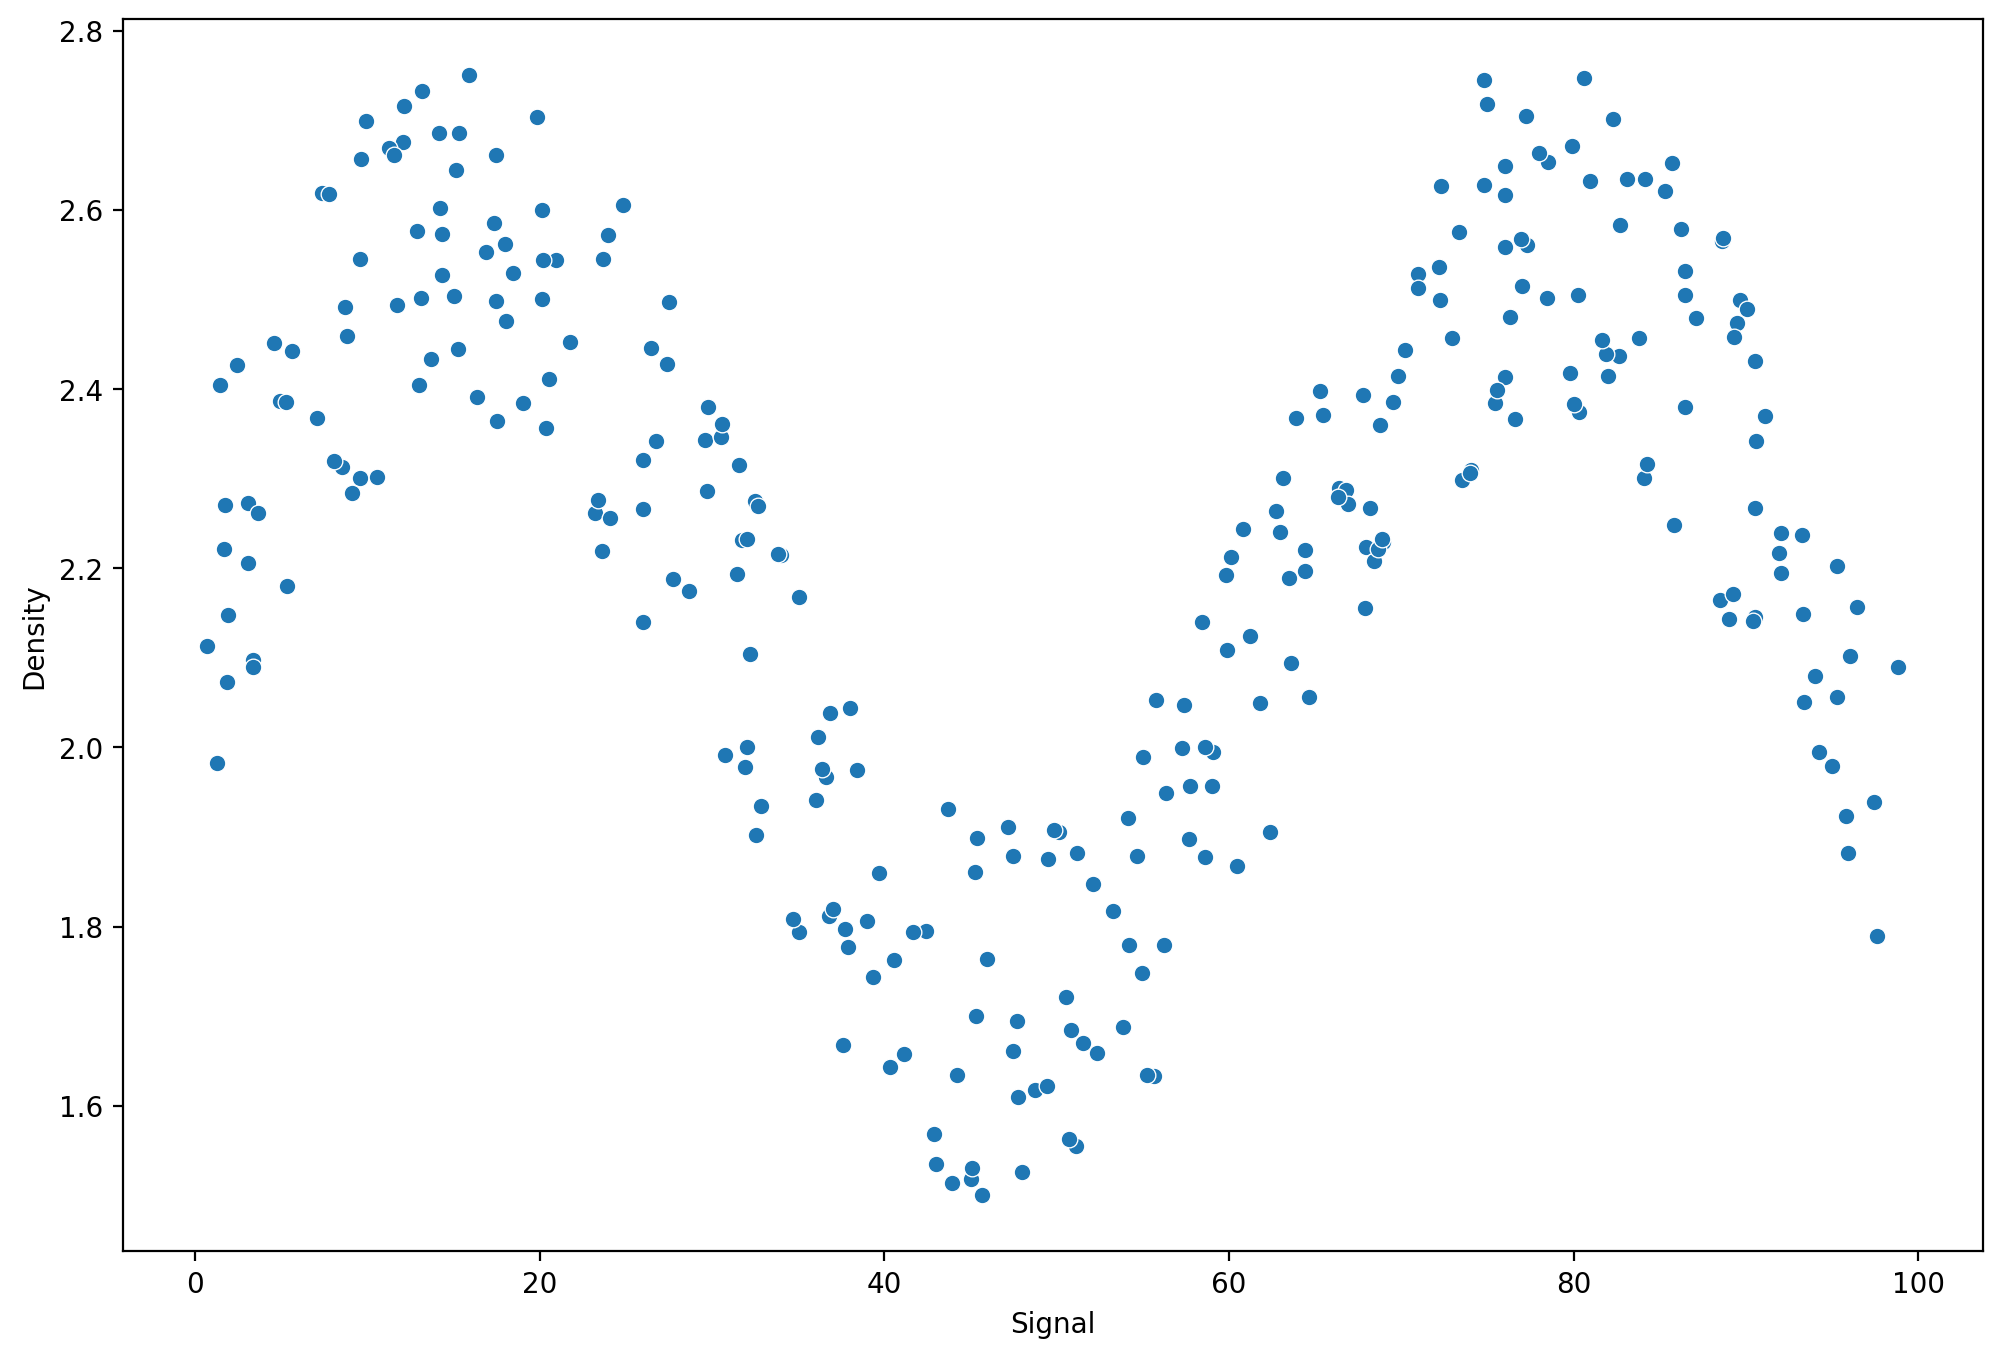

In [139]:
df.columns=['Signal',"Density"]
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

In [140]:
from sklearn.model_selection import train_test_split
X = df['Signal'].values.reshape(-1,1)  
y = df['Density']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [141]:
from sklearn.metrics import mean_squared_error
def run_model(model,X_train,y_train,X_test,y_test):
    
    # Fit Model
    model.fit(X_train,y_train)
    
    # Get Metrics
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    print(f'RMSE : {rmse}')
    
    # Plot results
    signal_range = np.arange(0,100)
    output = model.predict(signal_range.reshape(-1,1))
    
    
    plt.figure(figsize=(12,6),dpi=150)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')
    plt.plot(signal_range,output)

RMSE : 0.1523487028635337


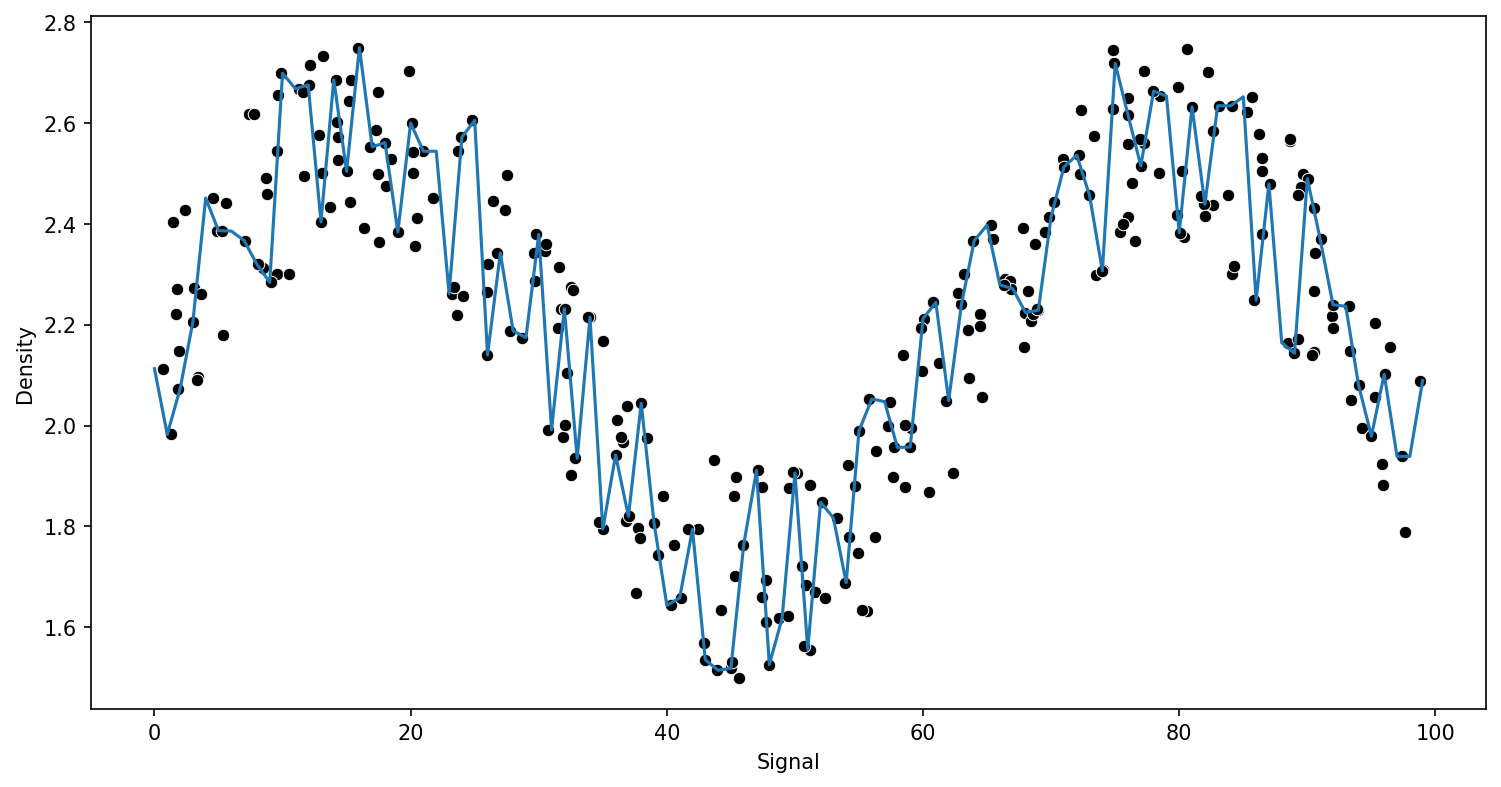

In [142]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()

run_model(model,X_train,y_train,X_test,y_test)